In [15]:
# Import modules

import os
os.environ["JAX_PLATFORM_NAME"] = "cpu"   # must happen before importing jax

import argparse
import jax
import numpy as np
import numpyro
from numpyro.infer import Predictive, MCMC, NUTS
import jax.numpy as jnp
from modelSpecification import likelihood_gb_speaker, likelihood_inc_speaker, global_speaker, speaker_recursive, literal_listener_recursive, import_dataset
import matplotlib.pyplot as plt
import seaborn as sns
numpyro.set_platform("cpu")
numpyro.set_host_device_count(4)
print(jax.__version__)
from jax.random import PRNGKey, split
from jax import random
import arviz as az
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

0.4.20


# Diagnostic on MCMC with global speaker

## Load idata from netCDF file

In [ ]:
inference_data_file_path = "./inference_data/mcmc_results_global_speaker_warmup1000_samples1000_chains4.nc"
idata = az.from_netcdf(inference_data_file_path)
print(az.summary(idata))
idata

                 mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
alpha           5.274  2.921   0.923   10.697      0.054    0.043    2608.0   
bias            5.365  2.853   1.041   10.791      0.046    0.038    3352.0   
color_semvalue  0.724  0.131   0.481    0.954      0.002    0.002    3728.0   
k               0.271  0.129   0.041    0.498      0.002    0.002    3194.0   
sigma           0.621  0.015   0.593    0.650      0.000    0.000    4273.0   

                ess_tail  r_hat  
alpha             2650.0    1.0  
bias              2555.0    1.0  
color_semvalue    2725.0    1.0  
k                 2035.0    1.0  
sigma             2914.0    1.0  


Inference data with groups:
	> posterior
	> posterior_predictive
	> log_likelihood
	> sample_stats
	> prior
	> prior_predictive
	> observed_data

## Traceplot

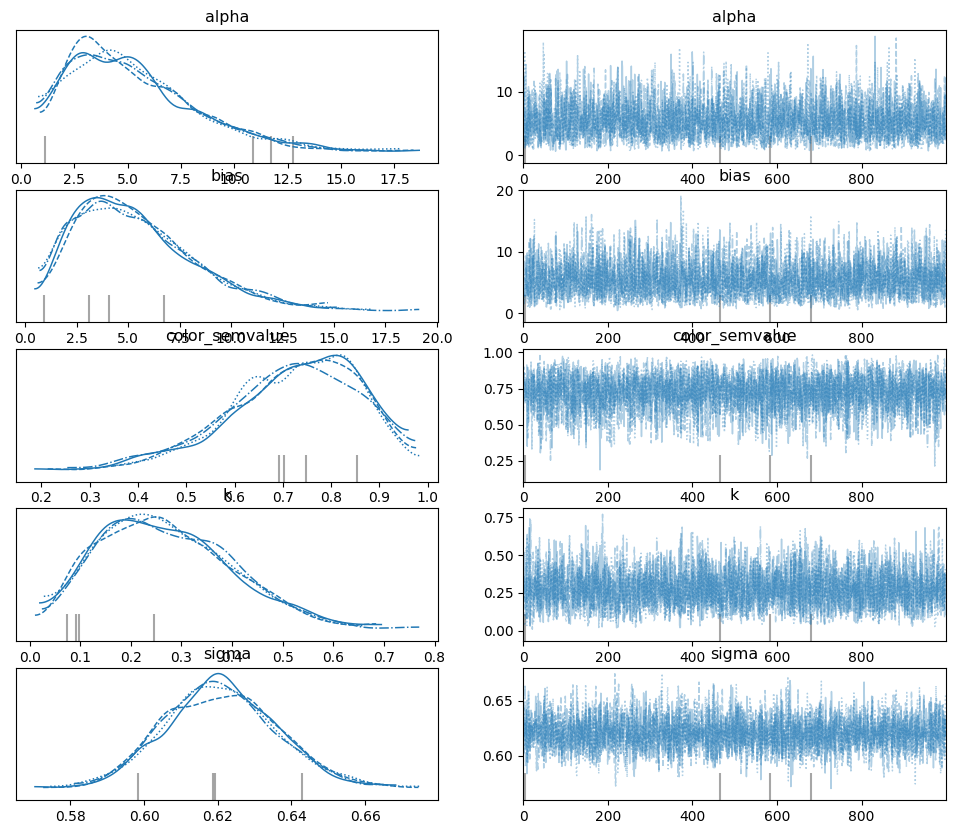

In [4]:
az.plot_trace(idata)
plt.show()

## Plot prior agianst posterior

array([[<Axes: >, <Axes: >, <Axes: xlabel='alpha'>],
       [<Axes: >, <Axes: >, <Axes: xlabel='bias'>],
       [<Axes: >, <Axes: >, <Axes: xlabel='color_semvalue'>],
       [<Axes: >, <Axes: >, <Axes: xlabel='k'>],
       [<Axes: >, <Axes: >, <Axes: xlabel='sigma'>]], dtype=object)

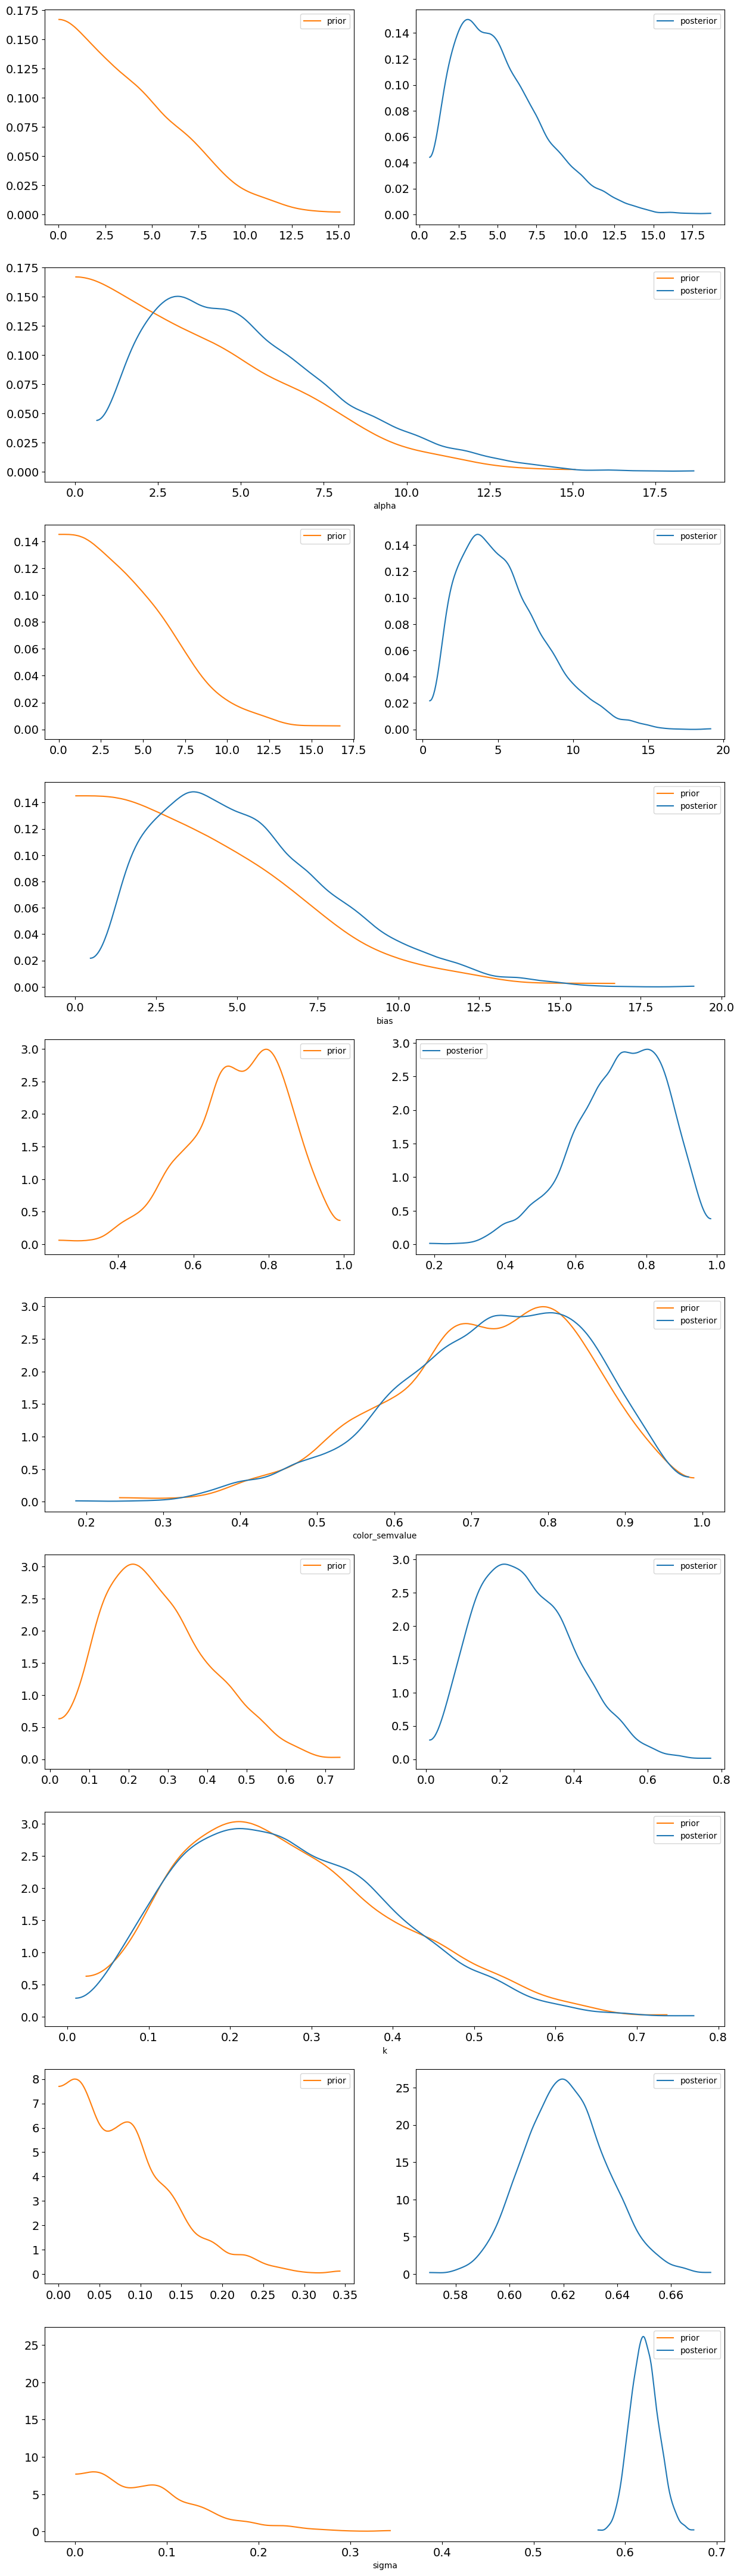

In [7]:
az.plot_dist_comparison(
    idata,
    var_names=["alpha", "bias", "color_semvalue", "k", "sigma"]
)

## Autocorrelation

array([[<Axes: title={'center': 'alpha\n0'}>,
        <Axes: title={'center': 'alpha\n1'}>,
        <Axes: title={'center': 'alpha\n2'}>,
        <Axes: title={'center': 'alpha\n3'}>],
       [<Axes: title={'center': 'bias\n0'}>,
        <Axes: title={'center': 'bias\n1'}>,
        <Axes: title={'center': 'bias\n2'}>,
        <Axes: title={'center': 'bias\n3'}>],
       [<Axes: title={'center': 'color_semvalue\n0'}>,
        <Axes: title={'center': 'color_semvalue\n1'}>,
        <Axes: title={'center': 'color_semvalue\n2'}>,
        <Axes: title={'center': 'color_semvalue\n3'}>],
       [<Axes: title={'center': 'k\n0'}>,
        <Axes: title={'center': 'k\n1'}>,
        <Axes: title={'center': 'k\n2'}>,
        <Axes: title={'center': 'k\n3'}>],
       [<Axes: title={'center': 'sigma\n0'}>,
        <Axes: title={'center': 'sigma\n1'}>,
        <Axes: title={'center': 'sigma\n2'}>,
        <Axes: title={'center': 'sigma\n3'}>]], dtype=object)

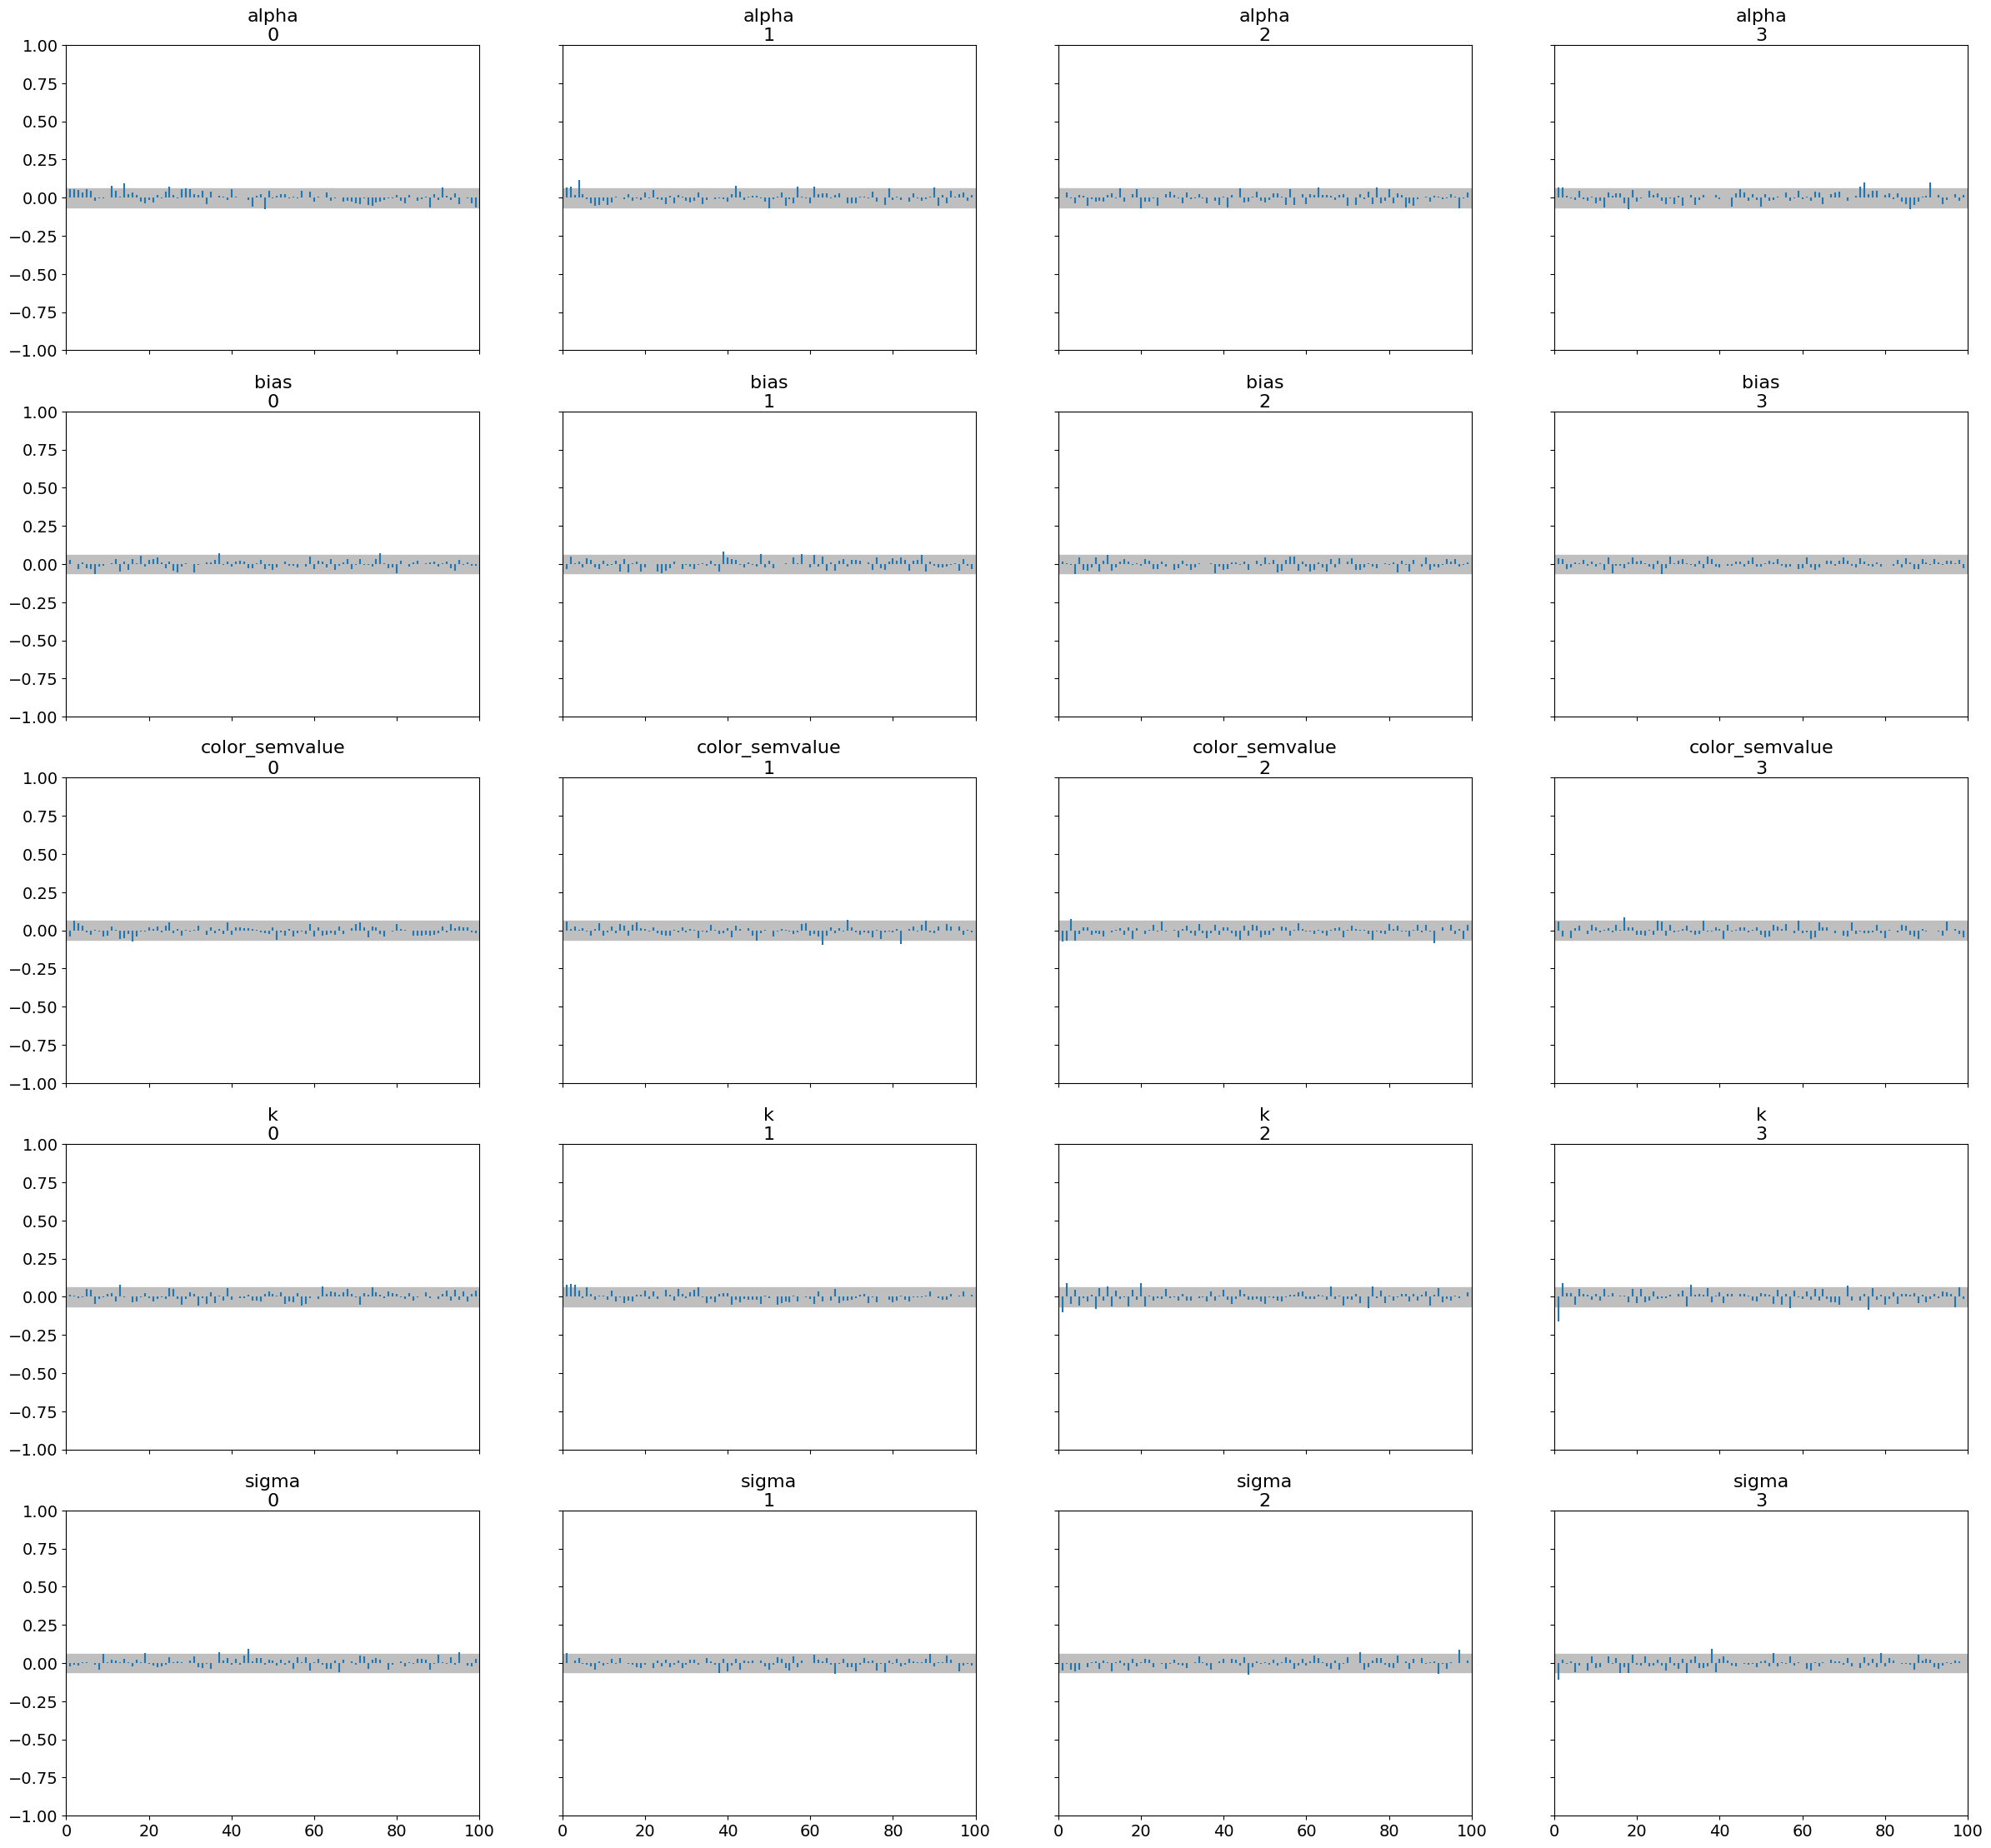

In [6]:
az.plot_autocorr(idata, var_names=["alpha", "bias", "color_semvalue", "k", "sigma"])

## Check paired correlation

array([[<Axes: ylabel='alpha'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >],
       [<Axes: ylabel='bias'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >],
       [<Axes: ylabel='color_semvalue'>, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >],
       [<Axes: ylabel='k'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >],
       [<Axes: xlabel='alpha', ylabel='sigma'>, <Axes: xlabel='bias'>,
        <Axes: xlabel='color_semvalue'>, <Axes: xlabel='k'>,
        <Axes: xlabel='sigma'>]], dtype=object)

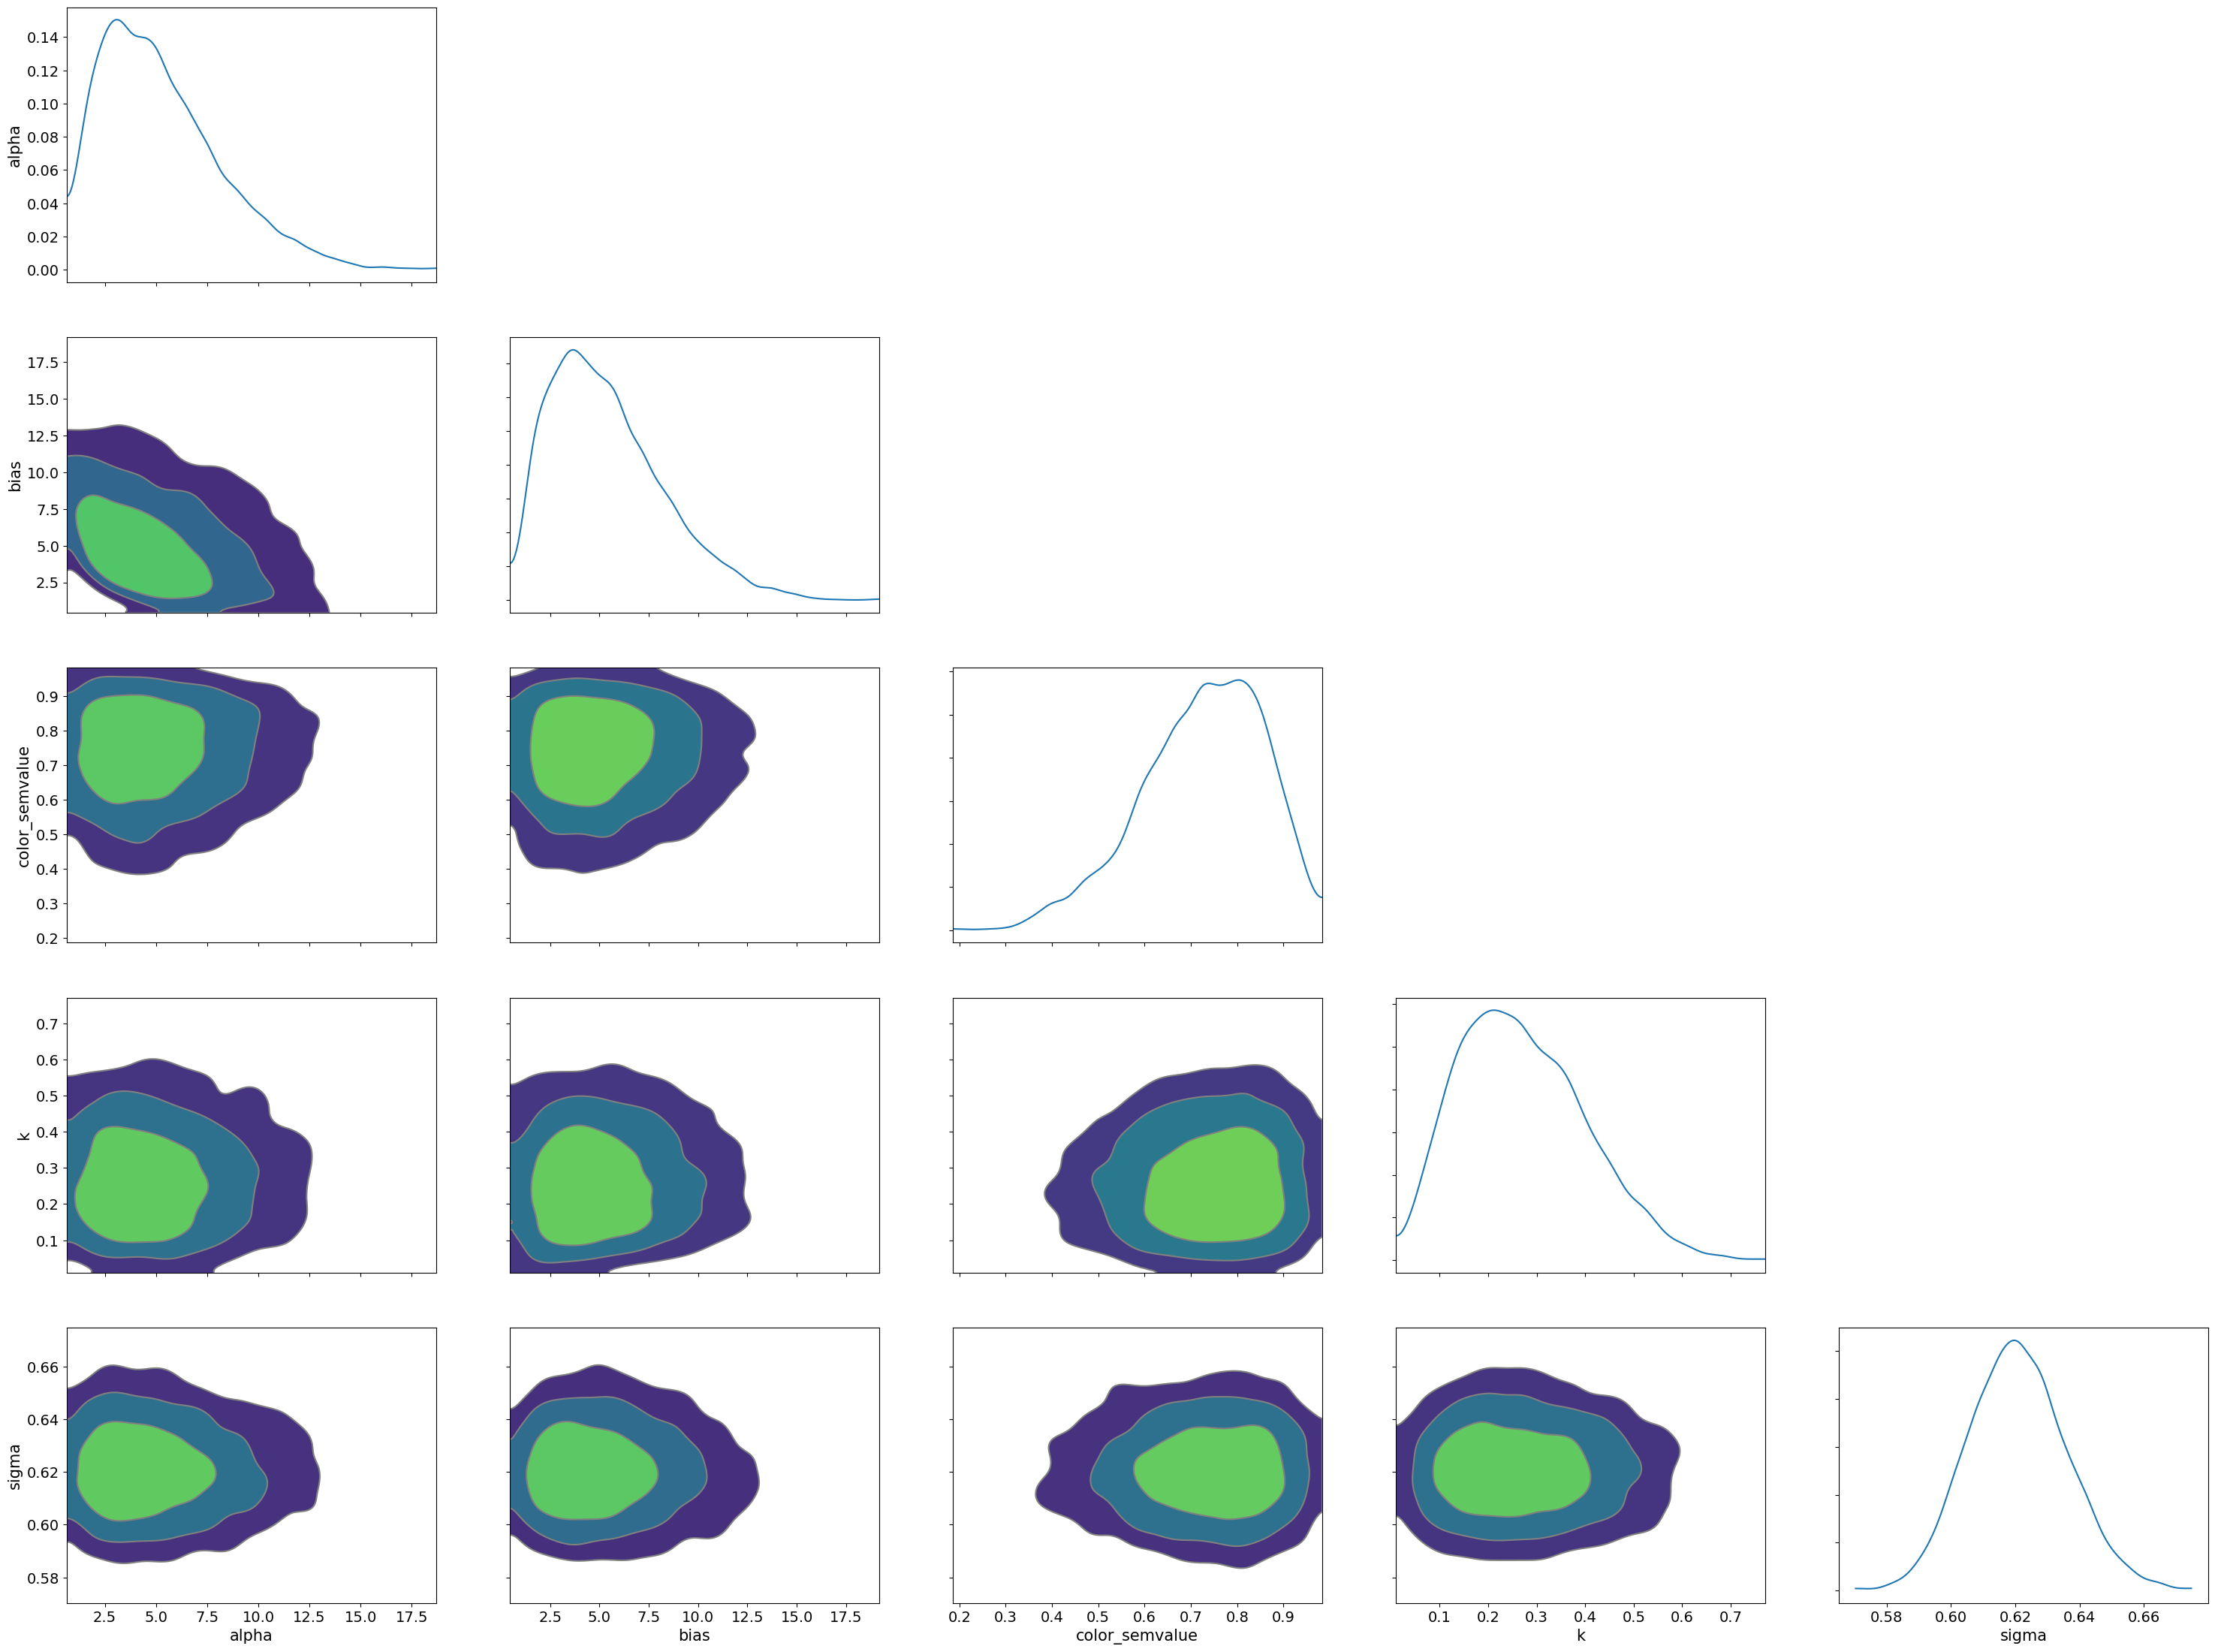

In [12]:
az.plot_pair(
    idata,
    var_names=["alpha", "bias", "color_semvalue", "k", "sigma"],
    kind="kde",
    marginals=True
)

## Prior Predictive

In [50]:
print(df.groupby(["sharpness","relevant_property"])["prefer_first_1st"].mean())

sharpness  relevant_property
blurred    both                 0.745602
           first                0.800422
           second               0.562261
sharp      both                 0.703920
           first                0.843005
           second               0.543468
Name: prefer_first_1st, dtype: float32


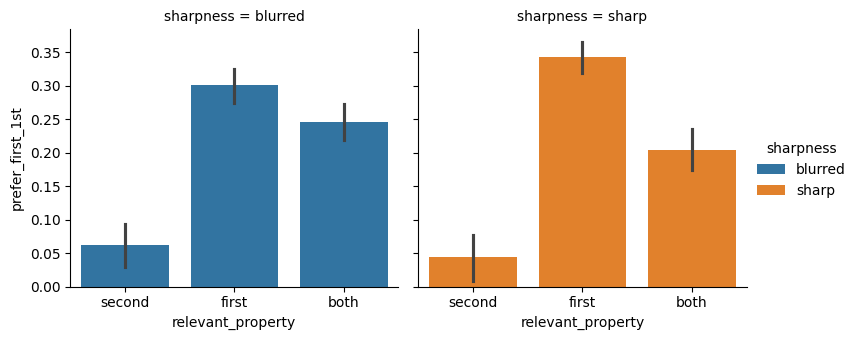

In [24]:


def plot_empirical_by_condition_distribution(
):
    # Load data
    _, _, df = import_dataset()
    
    y_centered = df["prefer_first_1st"] - 0.5

    # Plot bars (no seaborn errorbars; we draw them ourselves)
    g = sns.catplot(
        data=df,
        x="relevant_property",
        y=y_centered,
        hue="sharpness",
        col="sharpness",
        kind="bar",
        height=3.5,
        aspect=1.1,
        sharey=True,
    )

    return g


g = plot_empirical_by_condition_distribution(
)
plt.show()

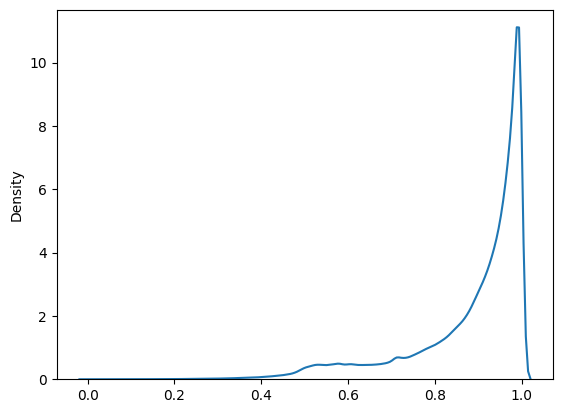

In [49]:
posterior_predictive = np.asarray(idata.prior_predictive["obs"]) # (chains, draws, observations)
posterior_predictive_flat = posterior_predictive.reshape(-1, posterior_predictive.shape[-1])
posterior_predictive_flat.shape  # (chains*draws, observations)
np.mean(posterior_predictive_flat)
sns.kdeplot(posterior_predictive_flat.flatten())
plt.show()
_, _, df = import_dataset()


In [51]:
assert len(df) == posterior_predictive.shape[-1]

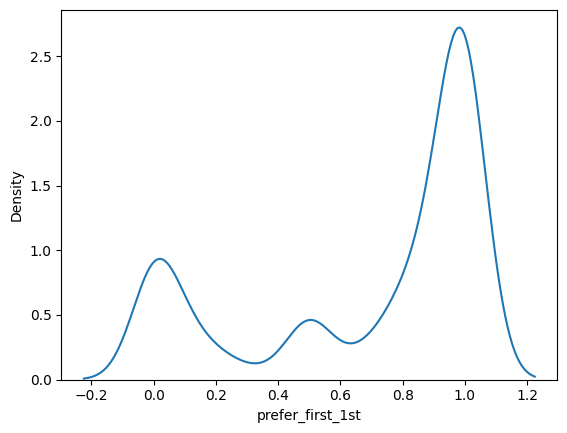

In [45]:
sns.kdeplot(df["prefer_first_1st"])
plt.show()

/var/folders/jc/6ctllcx143xbrgx01x69skg80000gn/T/ipykernel_44058/998422509.py:37: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  g = sns.catplot(
/Users/heningwang/Documents/GitHub/numpyro_adjective_modelling/jax-metal/lib/python3.11/site-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Users/heningwang/Documents/GitHub/numpyro_adjective_modelling/jax-metal/lib/python3.11/site-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


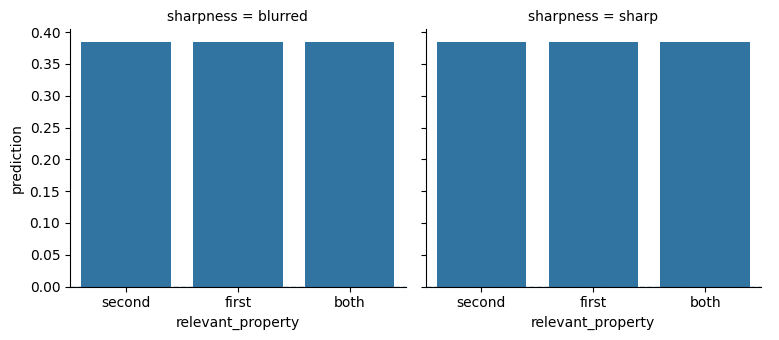

In [48]:

def plot_predicted_means_by_condition_long(
    predictions,
    x_col="relevant_property",
    facet_col="sharpness",
    y_center=0.5,
):
    """
    predictions: array (chain, draw, N) or (S, N)
    Builds long dataframe:
        one row = one posterior predictive draw for one trial
    """
    # Load empirical design
    _, _, df = import_dataset()
    df = df.copy()

    preds = np.asarray(predictions)
    if preds.ndim == 3:
        preds = preds.reshape(-1, preds.shape[-1])   # (S, N)
    elif preds.ndim != 2:
        raise ValueError(f"predictions must be (chain, draw, N) or (S, N)")

    S, N = preds.shape
    if len(df) != N:
        raise ValueError("Prediction axis does not align with df rows")

    # Center predictions (mirror empirical plot)
    preds = preds - y_center

    # ---- build long dataframe (vectorized)
    # repeat design rows S times
    design_long = pd.concat([df[[x_col, facet_col]]] * S, ignore_index=True)

    # flatten predictions to match
    design_long["prediction"] = preds.reshape(-1)

    # ---- plot: seaborn aggregates over posterior samples automatically
    g = sns.catplot(
        data=design_long,
        x=x_col,
        y="prediction",
        col=facet_col,
        kind="bar",
        height=3.5,
        aspect=1.1,
        sharey=True,
        errorbar=('ci', 95),              # seaborn CI (bootstrap by default)
    )

    for ax in g.axes.flat:
        ax.axhline(0, linestyle="--", linewidth=1)

    plt.tight_layout()
    return g, design_long

g, design_long = plot_predicted_means_by_condition_long(
    predictions=posterior_predictive,
    y_center=0.5,
)
plt.show()

I use this function to plot empirical: 

def plot_empirical_by_condition_distribution(
):
    # Load data
    _, _, df = import_dataset()
    
    y_centered = df["prefer_first_1st"] - 0.5

    # Plot bars (no seaborn errorbars; we draw them ourselves)
    g = sns.catplot(
        data=df,
        x="relevant_property",
        y=y_centered,
        hue="sharpness",
        col="sharpness",
        kind="bar",
        height=3.5,
        aspect=1.1,
        sharey=True,
    )

    return g
And I got this raw predictive data from my MCMC: idata.posterior_predictive.obs.shape, (4, 1000, 3485) 
I want to plot the mean predictions aggregated by conditions (also collapsd with chains and multiple samples)

## Posterior Predictive

# Diagnostic with incremental speaker

## Load idata

In [52]:
inference_data_file_path_incremental = "./inference_data/mcmc_results_incremental_speaker_warmup1000_samples1000_chains4.nc"
idata_inc = az.from_netcdf(inference_data_file_path_incremental)
print(az.summary(idata_inc))

                 mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
bias            0.832  0.030   0.774    0.887      0.000    0.000    4346.0   
color_semvalue  0.687  0.130   0.500    0.915      0.002    0.002    3875.0   
gamma           0.021  0.025   0.000    0.067      0.000    0.001    2952.0   
k               0.454  0.289   0.001    0.924      0.004    0.003    4431.0   
sigma           0.381  0.005   0.373    0.390      0.000    0.000    4717.0   

                ess_tail  r_hat  
bias              3114.0    1.0  
color_semvalue    1955.0    1.0  
gamma             1955.0    1.0  
k                 2753.0    1.0  
sigma             2484.0    1.0  


## Traceplot

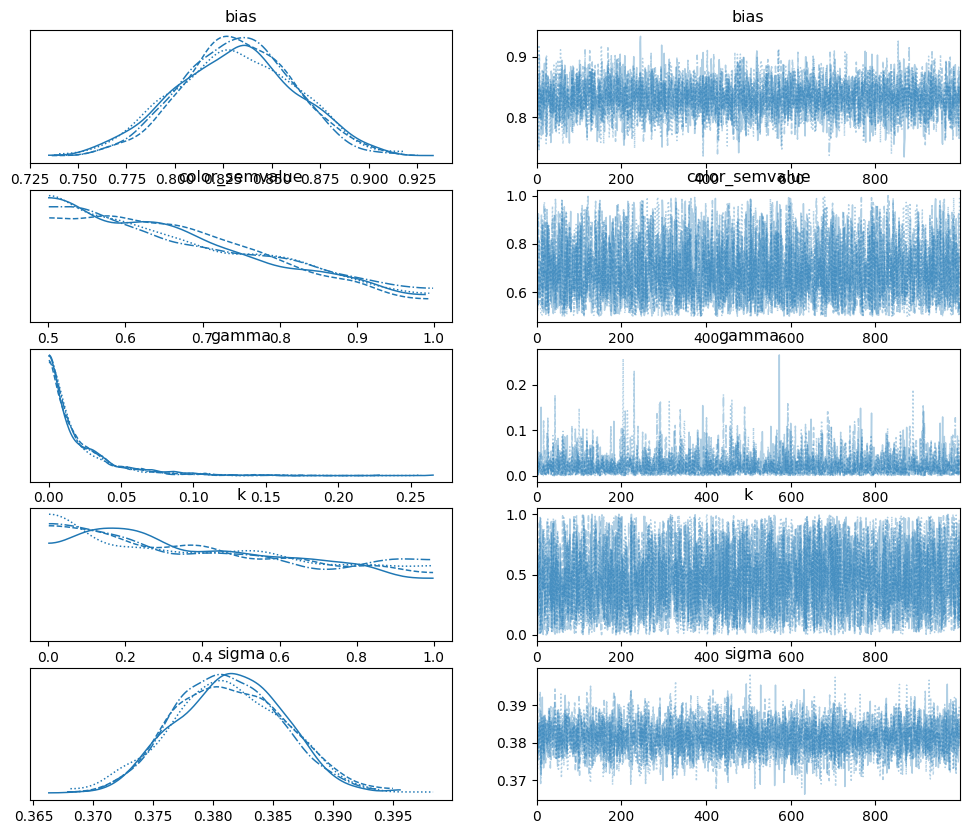

In [54]:
az.plot_trace(idata_inc)
plt.show()

## Plot prior against posterior

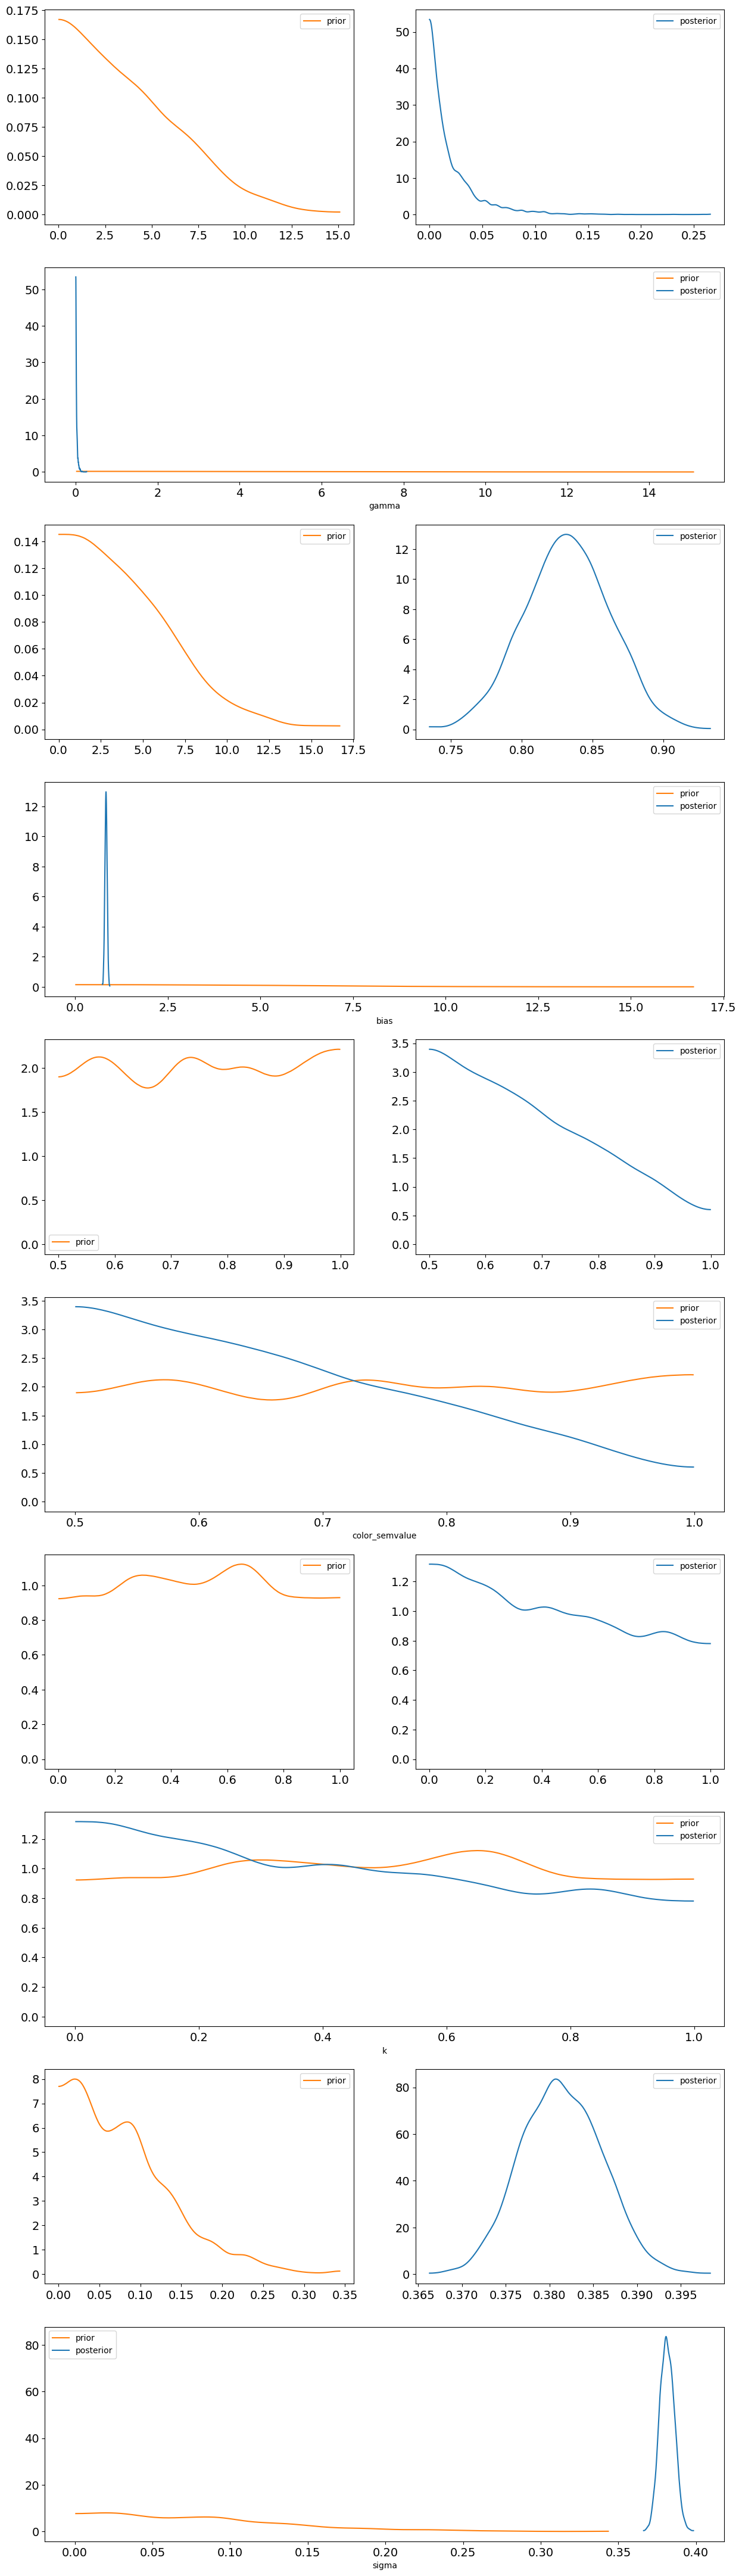

In [56]:
az.plot_dist_comparison(
    idata_inc,
    var_names=["gamma", "bias", "color_semvalue", "k", "sigma"]
)
plt.show()

## Autocorrelation

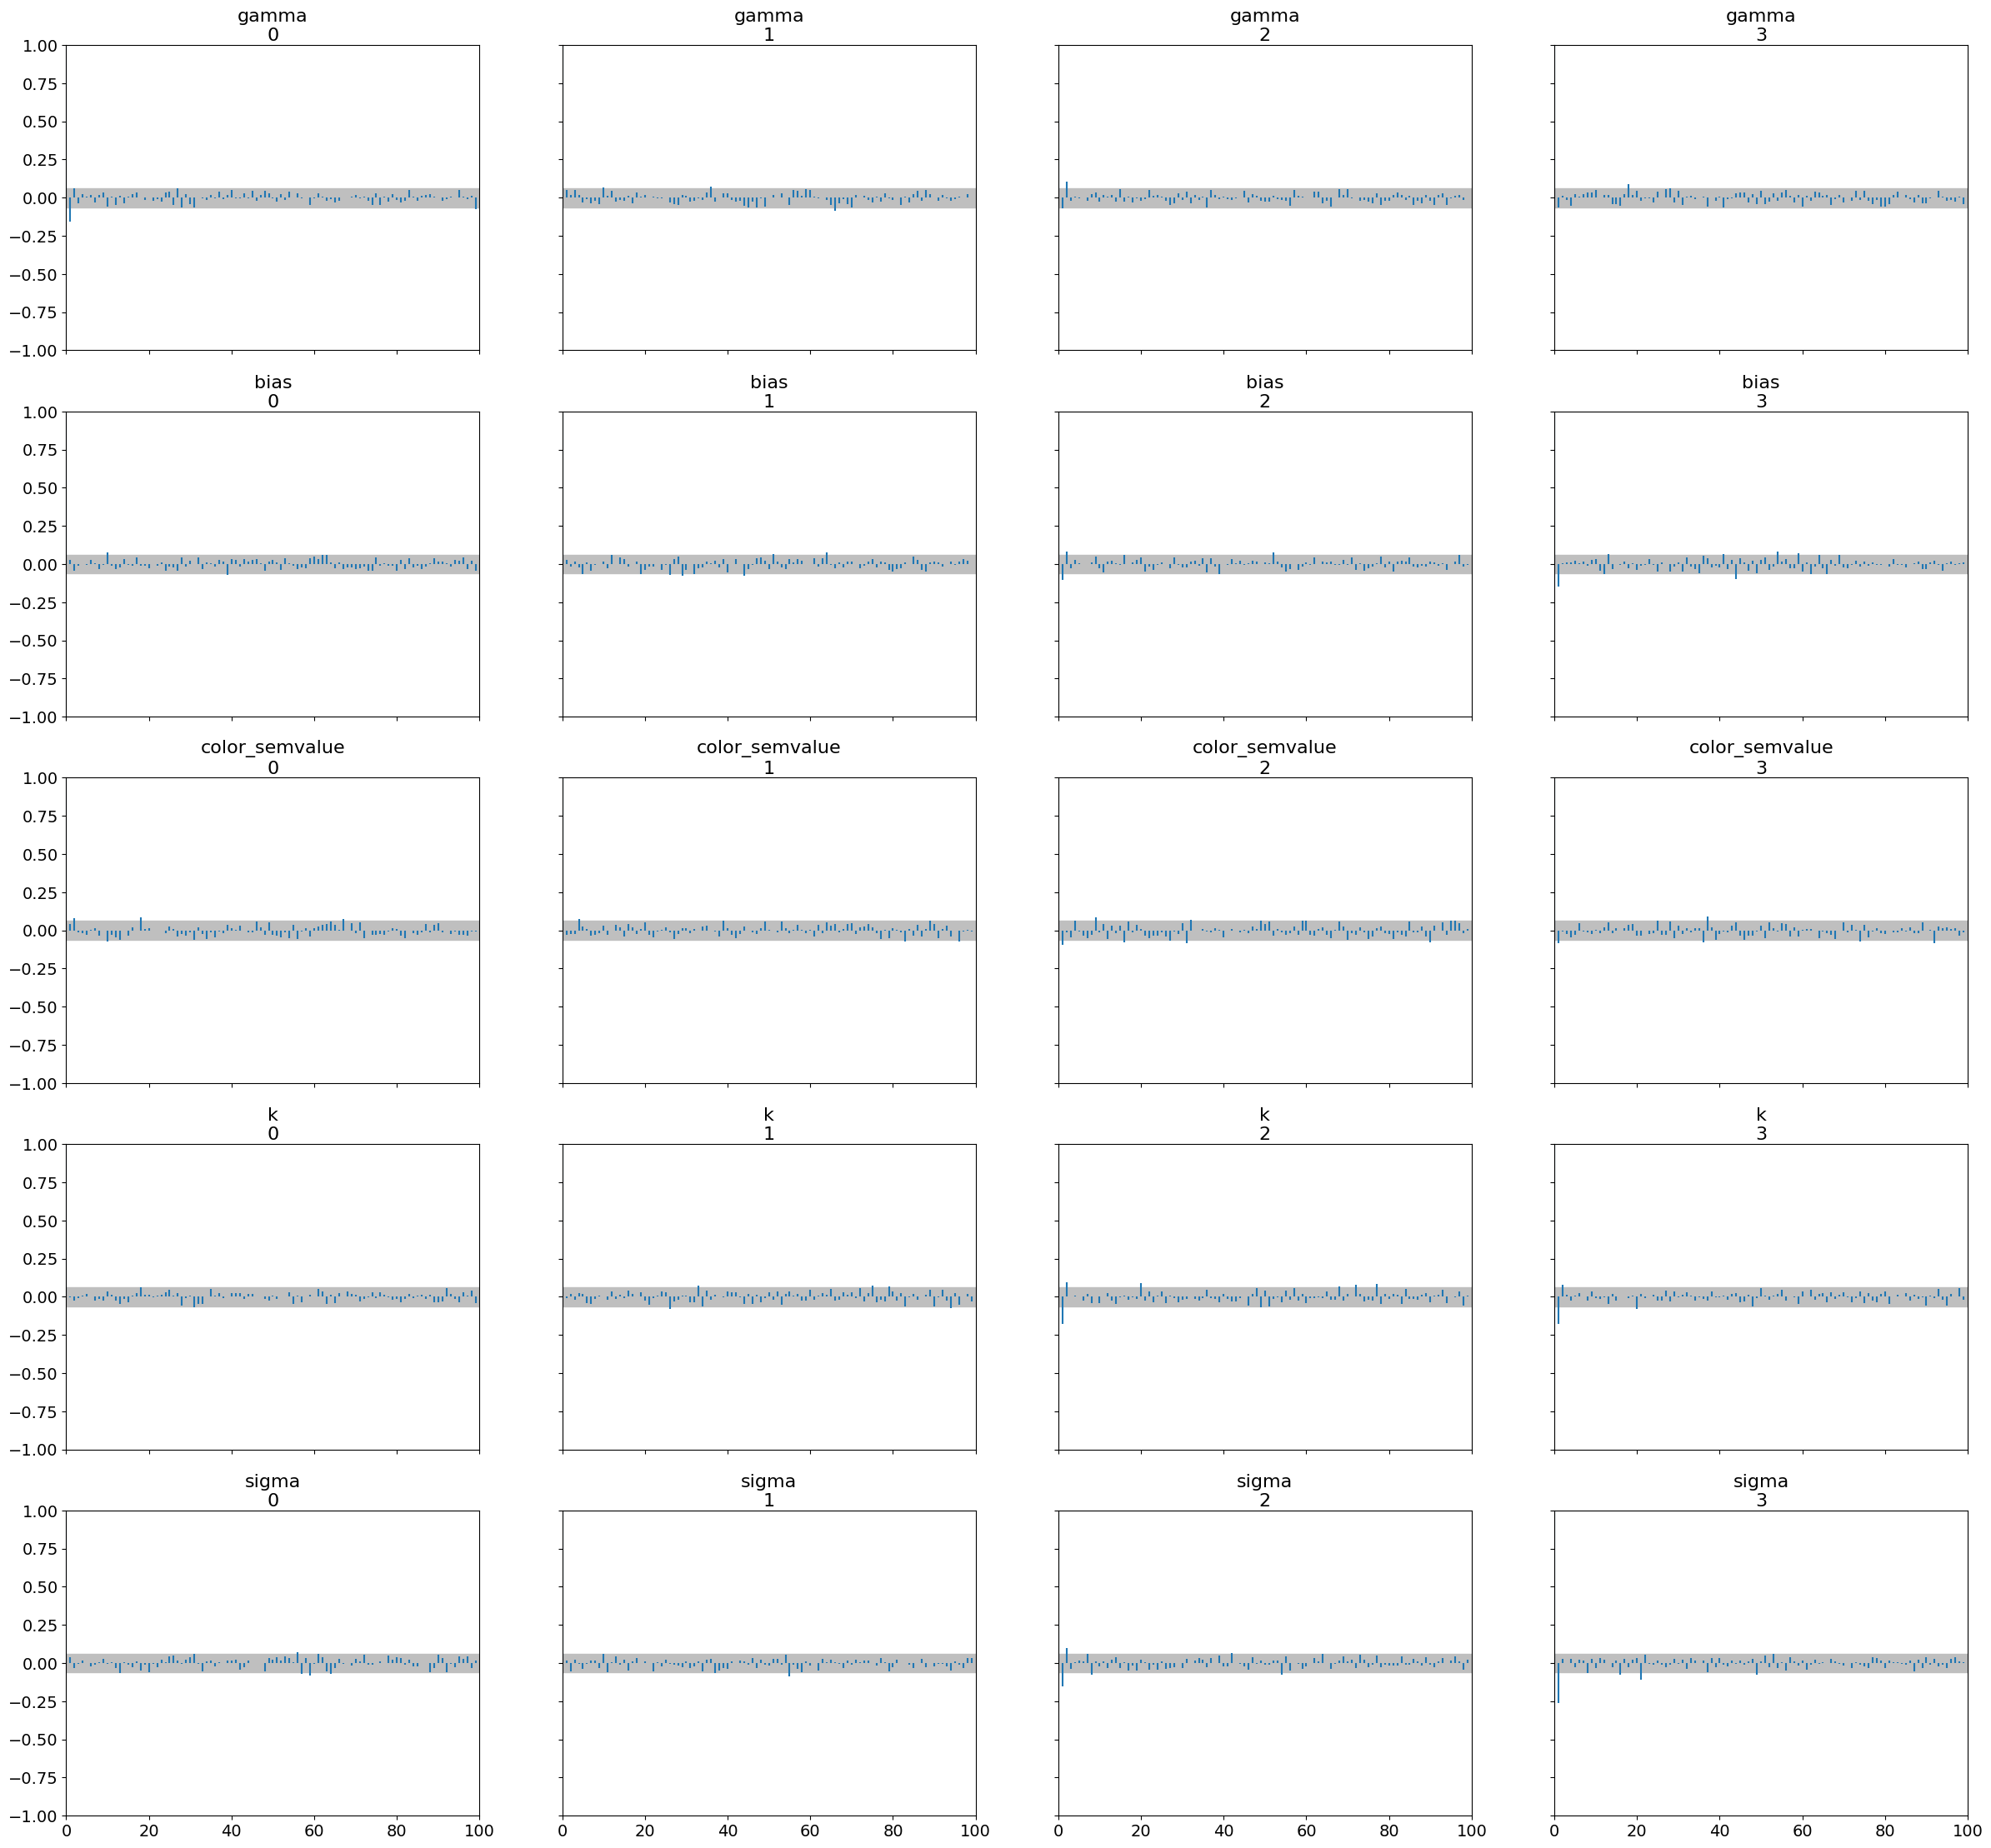

In [57]:
az.plot_autocorr(idata_inc, var_names=["gamma", "bias", "color_semvalue", "k", "sigma"])
plt.show()

# Plot pairwise correlation

array([[<Axes: ylabel='gamma'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >],
       [<Axes: ylabel='bias'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >],
       [<Axes: ylabel='color_semvalue'>, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >],
       [<Axes: ylabel='k'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >],
       [<Axes: xlabel='gamma', ylabel='sigma'>, <Axes: xlabel='bias'>,
        <Axes: xlabel='color_semvalue'>, <Axes: xlabel='k'>,
        <Axes: xlabel='sigma'>]], dtype=object)

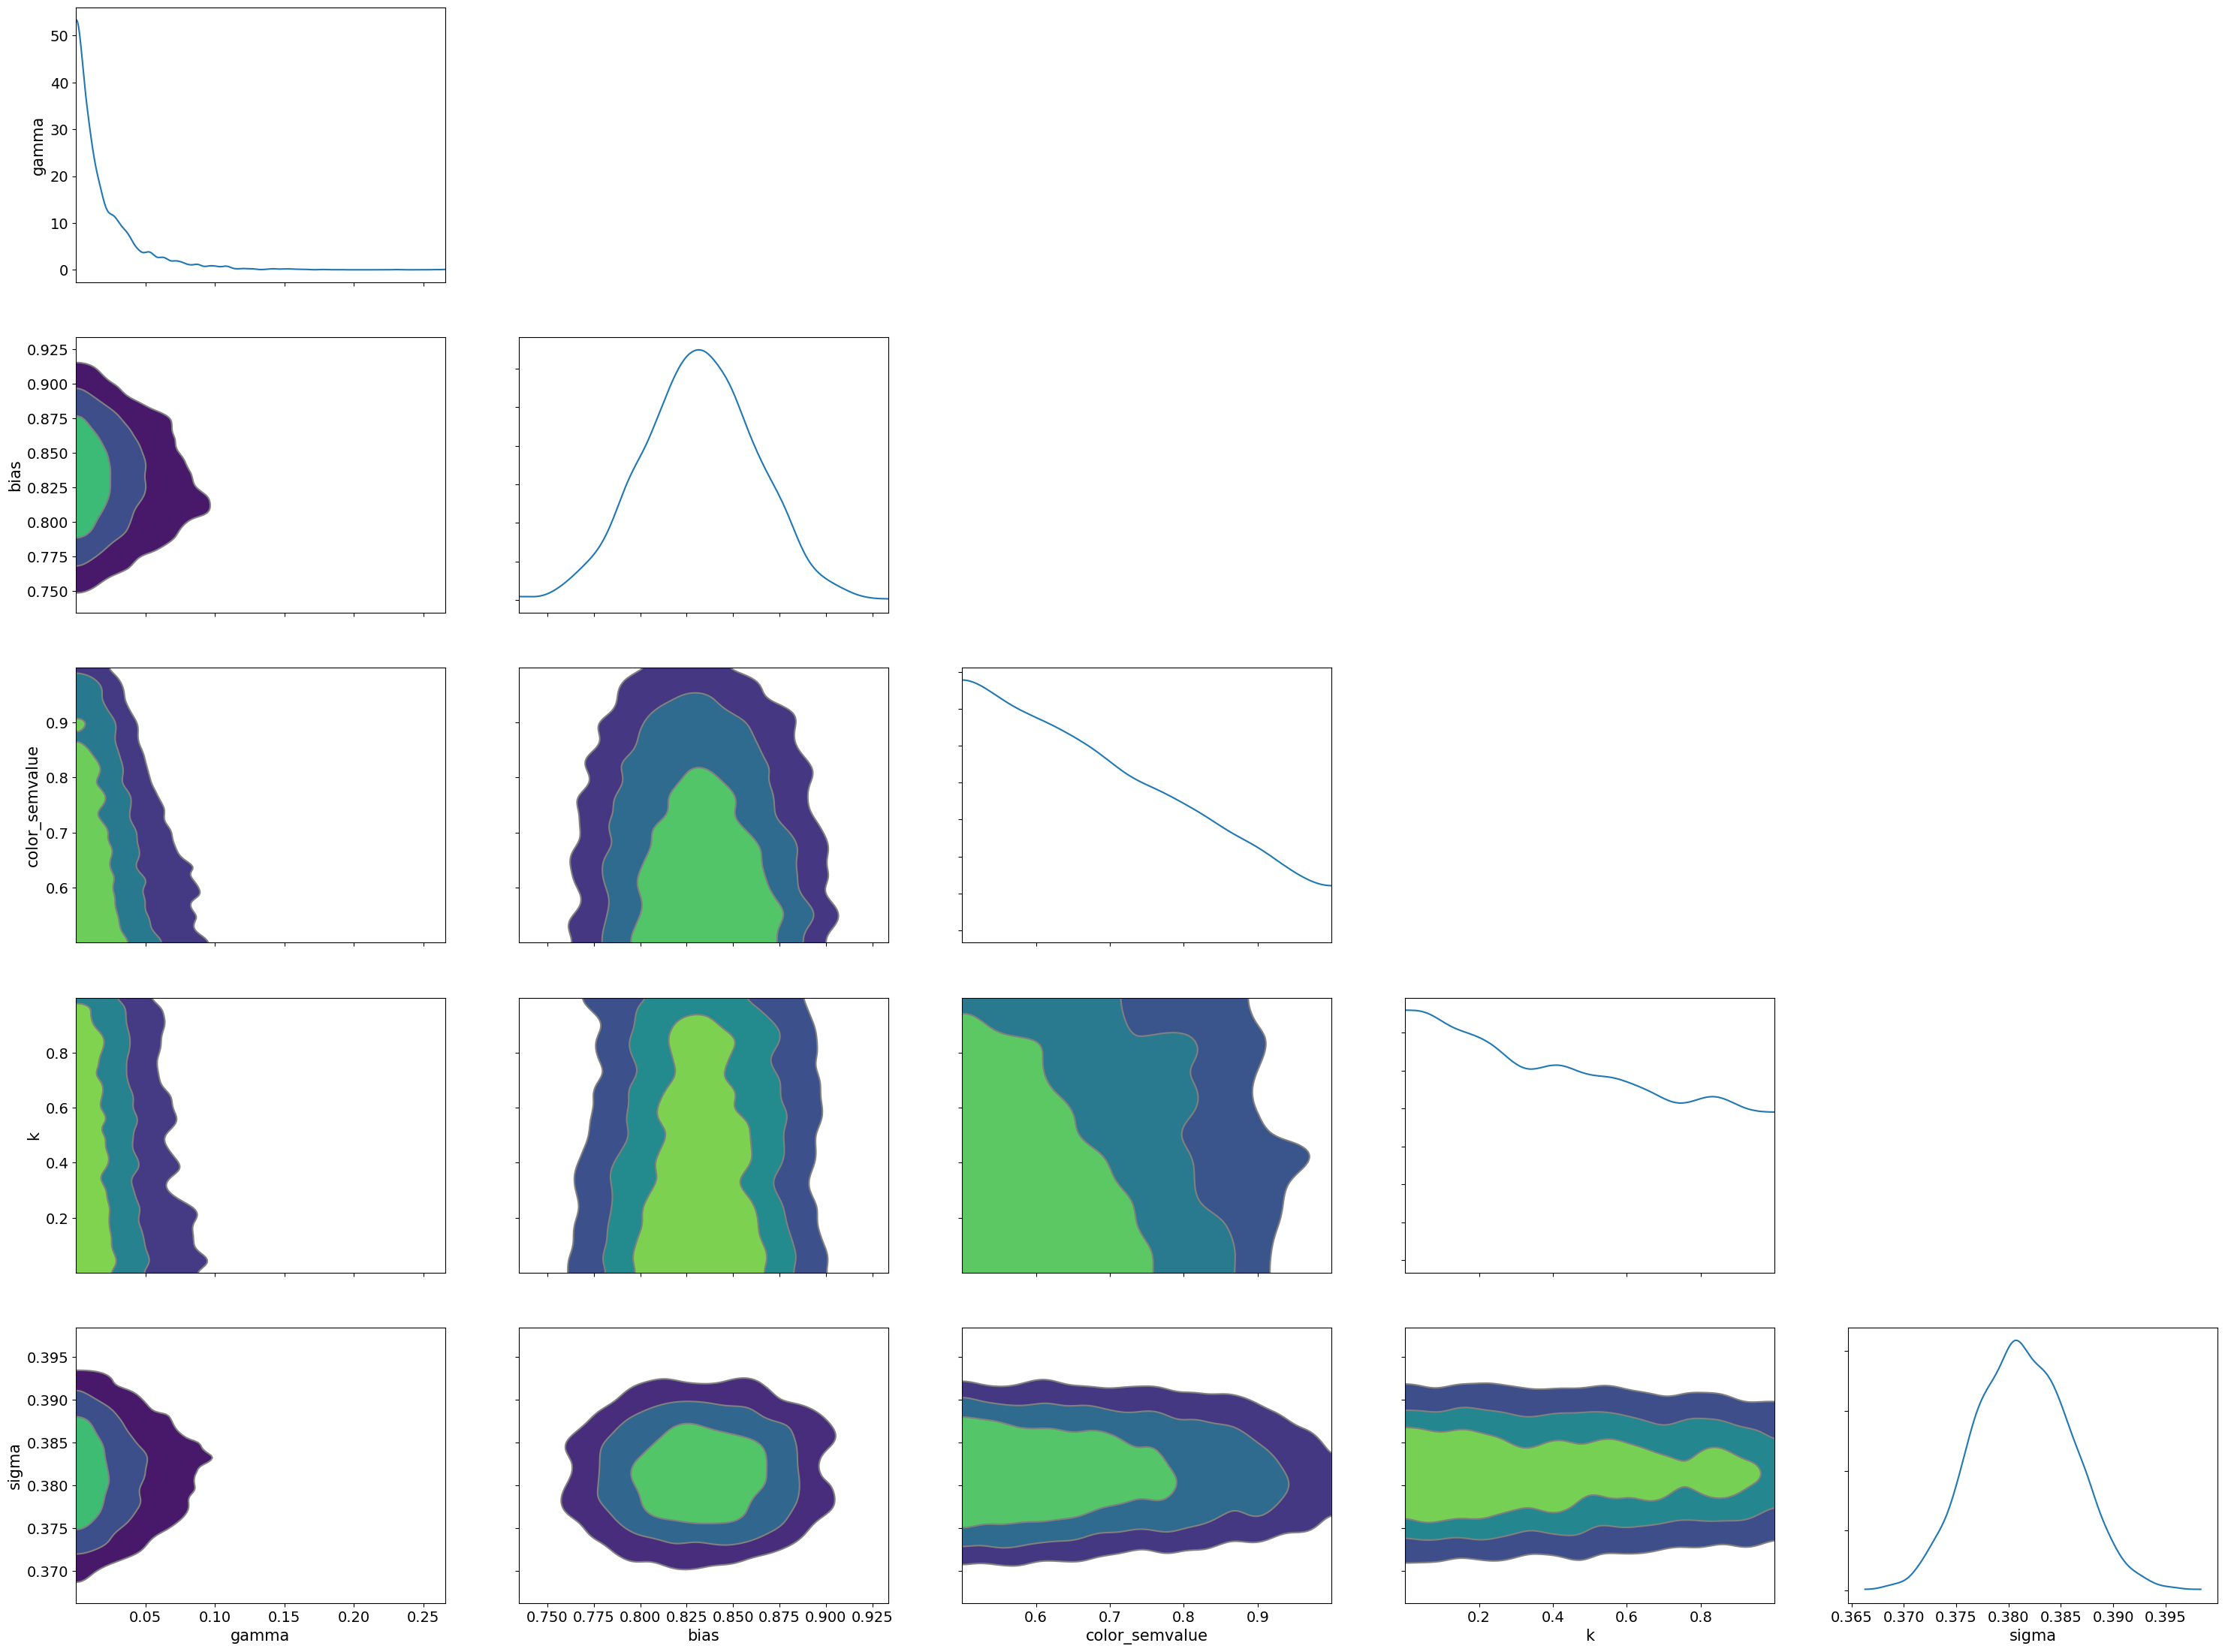

In [59]:
az.plot_pair(
    idata_inc,
    var_names=["gamma", "bias", "color_semvalue", "k", "sigma"],
    kind="kde",
    marginals=True
)

## Plot posterior predictive

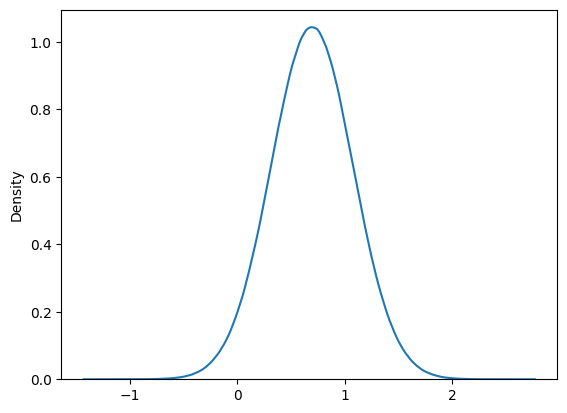

/var/folders/jc/6ctllcx143xbrgx01x69skg80000gn/T/ipykernel_44058/998422509.py:37: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  g = sns.catplot(
/Users/heningwang/Documents/GitHub/numpyro_adjective_modelling/jax-metal/lib/python3.11/site-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Users/heningwang/Documents/GitHub/numpyro_adjective_modelling/jax-metal/lib/python3.11/site-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


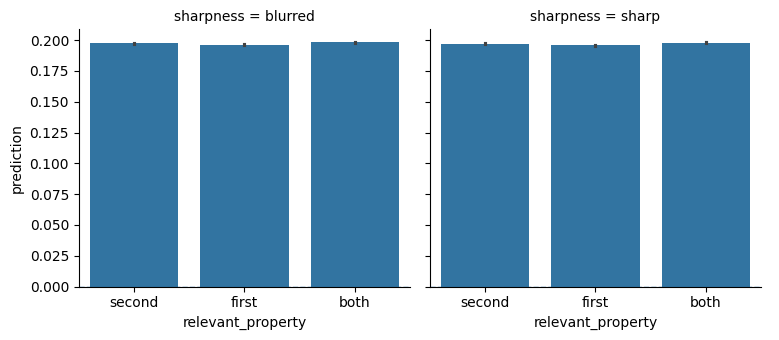

In [61]:
posterior_predictive = np.asarray(idata_inc.posterior_predictive["obs"]) # (chains, draws, observations)
posterior_predictive_flat = posterior_predictive.reshape(-1, posterior_predictive.shape[-1])
posterior_predictive_flat.shape  # (chains*draws, observations)
np.mean(posterior_predictive_flat)
sns.kdeplot(posterior_predictive_flat.flatten())
plt.show()
_, _, df = import_dataset()

plot_predicted_means_by_condition_long(
    predictions=posterior_predictive,
    y_center=0.5,
)
plt.show()